# Demand Projections: Pakistan (R12_PAK) + Rest of South Asia (R12_RSAS)

Projects useful-level energy demands for SSP1, SSP2, SSP5, and Acc scenarios (2020-2070).

**Methodology:**
- **SSP1/2/5**: Convergence-based downscaling from R12_SAS regional totals anchored to 2020 historical activity
- **Transport (SSP1/2/5)**: Scaled from Original_SSP2 baseline using inter-scenario % differences *before* Acc regression
- **Acc (Pakistan)**: GDP/population regression trained on final (transport-adjusted) SSP1/2/5 demands
- **Acc (RSAS)**: SSP5 RSAS values (regional consistency)
- **i_feed**: Growth-rate approach from R12_SAS aggregated materials

## 1. Configuration

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

scripts_dir = Path('D:/COMMITTED/Models/Model-Manuscript/scripts')
sys.path.insert(0, str(scripts_dir))
from downscale_demands import downscale_demands

input_path  = Path('D:/COMMITTED/Models/Model-Manuscript/data/demands/inputs')
output_path = Path('D:/COMMITTED/Models/Model-Manuscript/data/demands/outputs/Non-Adjusted')
output_path.mkdir(parents=True, exist_ok=True)

pakistan_model = input_path / 'historicalPakistan.xlsx'
global_path    = input_path / 'global'
ssp_snap_file  = input_path / 'ssp_snapshot_1765877483.xlsx'
acc_macro_file = input_path / 'acc_macro_stable.csv'
orig_ssp2_file = input_path / 'Original_SSP2_PAK.xlsx'

hist_year      = 2020
model_years    = list(range(2020, 2071, 5))
rsas_countries = ['Afghanistan', 'Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Sri Lanka']
regions        = {'Pakistan': 'PAK', 'Rest_of_South_Asia': 'RSAS'}


## 2. Historical Activity

In [2]:
# Pakistan historical activity
pak_hist = pd.read_excel(pakistan_model, sheet_name='historical_activity')
pak_hist = pak_hist[pak_hist['node_loc'] == 'R12_PAK'].copy()

# R12_SAS historical activity (same across all SSPs)
sas_hist = pd.read_excel(global_path / 'SSP2-Baseline.xlsx', sheet_name='historical_activity')
sas_hist = sas_hist[sas_hist['node_loc'] == 'R12_SAS'].copy()

# RSAS = SAS - Pakistan
keys = ['technology', 'year_act', 'mode', 'time']
merged = pd.merge(
    sas_hist[keys + ['value', 'unit']],
    pak_hist[keys + ['value']],
    on=keys, how='outer', suffixes=('_sas', '_pak')
)
merged[['value_sas', 'value_pak']] = merged[['value_sas', 'value_pak']].fillna(0)
rsas_hist = merged[keys + ['unit']].copy()
rsas_hist['value'] = (merged['value_sas'] - merged['value_pak']).clip(lower=0)
rsas_hist.insert(0, 'node_loc', 'Rest_of_South_Asia')

pak_norm = pak_hist.copy()
pak_norm['node_loc'] = 'Pakistan'
combined_hist = pd.concat([pak_norm, rsas_hist], ignore_index=True)
print(f"Historical activity: Pakistan={len(pak_norm)}, RSAS={len(rsas_hist)}")


Historical activity: Pakistan=1195, RSAS=2667


## 3. SSP GDP/Population

In [3]:
# SSP GDP/Population for Pakistan and RSAS (SSP1, SSP2, SSP5 only)
ssp_raw  = pd.read_excel(ssp_snap_file, sheet_name='data')
gdp_data = ssp_raw[ssp_raw['Variable'] == 'GDP|PPP'].copy()
pop_data = ssp_raw[ssp_raw['Variable'] == 'Population'].copy()
avail_yr = [c for c in ssp_raw.columns if str(c).isdigit()]
hist_gdp = gdp_data[gdp_data['Scenario'] == 'Historical Reference']
hist_pop = pop_data[pop_data['Scenario'] == 'Historical Reference']

gdp_list, pop_list = [], []
for ssp in ['SSP1', 'SSP2', 'SSP5']:
    for region in ['Pakistan'] + rsas_countries:
        for data, hist, out_list in [(gdp_data, hist_gdp, gdp_list), (pop_data, hist_pop, pop_list)]:
            r = data[(data['Scenario'] == ssp) & (data['Region'] == region)].copy()
            h = hist[hist['Region'] == region]
            if r.empty or h.empty:
                continue
            for col in avail_yr:
                if int(col) <= 2020:
                    r[col] = h[col].values[0]
            out_list.append(r)

all_gdp = pd.concat(gdp_list, ignore_index=True)
all_pop = pd.concat(pop_list, ignore_index=True)

def to_long(df, val_col):
    return (pd.melt(df, id_vars=['Scenario', 'Region'], value_vars=avail_yr,
                    var_name='year', value_name=val_col)
            .assign(year=lambda x: x['year'].astype(int)))

gdp_long = to_long(all_gdp, 'gdp')
pop_long = to_long(all_pop, 'pop')

pak_gdp  = gdp_long[gdp_long['Region'] == 'Pakistan']
pak_pop  = pop_long[pop_long['Region'] == 'Pakistan']
rsas_gdp = (gdp_long[gdp_long['Region'].isin(rsas_countries)]
            .groupby(['Scenario', 'year'])['gdp'].sum().reset_index()
            .assign(Region='Rest_of_South_Asia'))
rsas_pop = (pop_long[pop_long['Region'].isin(rsas_countries)]
            .groupby(['Scenario', 'year'])['pop'].sum().reset_index()
            .assign(Region='Rest_of_South_Asia'))

ssp_combined = pd.merge(
    pd.concat([pak_gdp, rsas_gdp], ignore_index=True)[['Scenario', 'Region', 'year', 'gdp']],
    pd.concat([pak_pop, rsas_pop], ignore_index=True)[['Scenario', 'Region', 'year', 'pop']],
    on=['Scenario', 'Region', 'year']
)
ssp_combined['gdpc'] = 1e3 * ssp_combined['gdp'] / ssp_combined['pop']
print(f"SSP macro loaded: {list(ssp_combined['Scenario'].unique())}")


SSP macro loaded: ['SSP1', 'SSP2', 'SSP5']


## 4. Regional Demands (R12_SAS)

In [4]:
# Load R12_SAS regional demands + create i_feed from materials
material_commodities = ['cement', 'steel', 'aluminum', 'HVC', 'NH3', 'methanol']
regional_demands = {}

for ssp in ['SSP1', 'SSP2', 'SSP5']:
    df = pd.read_excel(global_path / f'{ssp}-Baseline.xlsx', sheet_name='demand')
    df = df[(df['node'] == 'R12_SAS') & (df['year'].between(hist_year, 2070))].copy()
    df['unit'] = df['unit'].replace('???', 'GWa')
    df['unit'] = df['unit'].replace('t', 'GWa')
    i_feed = (df[df['commodity'].isin(material_commodities)]
              .groupby(['node', 'year'])
              .agg(time=('time', 'first'), level=('level', 'first'),
                   value=('value', 'sum'), unit=('unit', 'first'))
              .reset_index()
              .assign(commodity='i_feed', level='useful'))
    regional_demands[ssp] = pd.concat([df, i_feed], ignore_index=True)
    v2050 = i_feed[i_feed['year'] == 2050]['value'].iloc[0]
    print(f"{ssp}: {len(df)} demand entries | i_feed 2050 = {v2050:.1f} GWa")


SSP1: 120 demand entries | i_feed 2050 = 1313.9 GWa
SSP2: 120 demand entries | i_feed 2050 = 1504.6 GWa
SSP5: 120 demand entries | i_feed 2050 = 2152.9 GWa


## 5. Downscaling Function

In [5]:
def project_demands_two_regions(regional_demands_df, ssp_data, regions_dict, hist_activity_df, scenario_name):
    """Project demands for Pakistan and RSAS using convergence-based downscaling."""
    region_names = list(regions_dict.keys())
    ssp_scenario = ssp_data[(ssp_data['Scenario'] == scenario_name) &
                             (ssp_data['Region'].isin(region_names))].copy()
    common_commodities = ['i_spec', 'i_therm', 'rc_spec', 'rc_therm', 'non-comm', 'transport', 'i_feed']
    cmdtys = [c for c in common_commodities if c in regional_demands_df['commodity'].unique()]
    output_df = pd.read_excel(global_path / 'SSP2-Baseline.xlsx', sheet_name='output')
    all_demands = []

    for cmdty in cmdtys:
        reg_demand = (regional_demands_df[regional_demands_df['commodity'] == cmdty]
                      .sort_values('year').reset_index(drop=True))
        if reg_demand.empty:
            continue
        level = reg_demand['level'].iloc[0]
        reg_demand['pc'] = reg_demand['value'].pct_change().replace([np.inf, -np.inf, np.nan], 0)

        # i_feed: grow Pakistan + RSAS baselines at R12_SAS growth rate
        if cmdty == 'i_feed':
            pak_demand = pd.read_excel(pakistan_model, sheet_name='demand')
            pak_base   = pak_demand[(pak_demand['commodity'] == 'i_feed') & (pak_demand['year'] == 2020)]
            pak_val    = float(pak_base['value'].iloc[0]) if not pak_base.empty else 0.0
            rsas_val   = reg_demand[reg_demand['year'] == 2020]['value'].iloc[0] - pak_val
            unit       = reg_demand['unit'].iloc[0]
            all_demands += [
                {'node': 'R12_PAK',  'commodity': 'i_feed', 'level': level, 'year': 2020,
                 'time': 'year', 'value': pak_val,  'unit': unit},
                {'node': 'R12_RSAS', 'commodity': 'i_feed', 'level': level, 'year': 2020,
                 'time': 'year', 'value': rsas_val, 'unit': unit},
            ]
            for _, row in reg_demand[reg_demand['year'] > 2020].iterrows():
                pak_val  *= (1 + row['pc'])
                rsas_val *= (1 + row['pc'])
                all_demands += [
                    {'node': 'R12_PAK',  'commodity': 'i_feed', 'level': level, 'year': row['year'],
                     'time': 'year', 'value': pak_val,  'unit': row['unit']},
                    {'node': 'R12_RSAS', 'commodity': 'i_feed', 'level': level, 'year': row['year'],
                     'time': 'year', 'value': rsas_val, 'unit': row['unit']},
                ]
            continue

        # Other commodities: convergence-based downscaling
        tec_list = (output_df[(output_df['commodity'] == cmdty) & (output_df['level'] == level)]
                    ['technology'].unique().tolist())
        dm_state = None

        for _, row in reg_demand.iterrows():
            year     = row['year']
            ssp_year = ssp_scenario[ssp_scenario['year'] == year]
            if ssp_year.empty:
                continue

            if dm_state is None:
                ha = (hist_activity_df[(hist_activity_df['year_act'] == year) &
                                       (hist_activity_df['technology'].isin(tec_list))]
                      .groupby('node_loc', as_index=False)['value'].sum())
                if ha.empty:
                    total_gdp = ssp_year['gdp'].sum()
                    ha = pd.DataFrame({'node_loc': ssp_year['Region'].values,
                                       'value': (ssp_year['gdp'].values / total_gdp) * row['value']})
                dm_state = pd.merge(ha, ssp_year[['Region', 'gdp', 'pop', 'gdpc']],
                                    left_on='node_loc', right_on='Region', how='left')
                dm_state[['gdp', 'gdpc']] = dm_state[['gdp', 'gdpc']].fillna(1.0)
                dm_state['ei'] = dm_state['value'] / dm_state['gdp']
            else:
                target = dm_state['value'].sum() * (1 + row['pc'])
                names  = dm_state['node_loc'].values
                try:
                    dm_result = downscale_demands(
                        target=target, initial=dm_state['value'].values,
                        income_i=dm_state['gdpc'].values,
                        income_f=ssp_year.set_index('Region').loc[names, 'gdpc'].values,
                        gdp_f=ssp_year.set_index('Region').loc[names, 'gdp'].values,
                        names=names
                    )
                    dm_state = (pd.merge(dm_result, ssp_year[['Region', 'gdp', 'pop', 'gdpc']],
                                         left_on='node', right_on='Region', how='left')
                                .rename(columns={'node': 'node_loc'}))
                    dm_state['ei'] = dm_state['value'] / dm_state['gdp']
                except Exception:
                    dm_state['value'] *= (1 + row['pc'])

            if dm_state is not None:
                for _, rrow in dm_state.iterrows():
                    code = regions_dict.get(rrow['node_loc'], rrow['node_loc'])
                    all_demands.append({
                        'node': 'R12_' + code, 'commodity': cmdty, 'level': level,
                        'year': year, 'time': 'year', 'value': rrow['value'], 'unit': row['unit']
                    })

    return pd.DataFrame(all_demands)


## 6. Project SSP1 / SSP2 / SSP5

In [6]:
projected_demands = {}
for ssp in ['SSP1', 'SSP2', 'SSP5']:
    print(f"Projecting {ssp}...")
    projected_demands[ssp] = project_demands_two_regions(
        regional_demands_df=regional_demands[ssp],
        ssp_data=ssp_combined,
        regions_dict=regions,
        hist_activity_df=combined_hist,
        scenario_name=ssp
    )
    print(f"  -> {len(projected_demands[ssp])} entries")


Projecting SSP1...
  -> 140 entries
Projecting SSP2...
  -> 140 entries
Projecting SSP5...
  -> 140 entries


## 7. Original SSP2 Anchoring (2030-2070, All Commodities)

In [ ]:
# Anchor all Pakistan demands to Original_SSP2 baseline for years 2030-2070
# SSP2: replaced directly by Original_SSP2 values
# SSP1/SSP5: Original_SSP2 * (1 + (downscaled - SSP2_downscaled) / SSP2_downscaled)
# Years 2020 and 2025 are left unchanged (historical anchor + near-term)

orig_pak  = pd.read_excel(orig_ssp2_file).set_index(["commodity", "year"])["value"]
adj_years = list(range(2030, 2071, 5))
commodities_adj = [ "transport", "i_spec", "i_therm", "rc_spec", "rc_therm", "i_feed"] # 

def pak_series(df, cmdty):
    return (df[(df["node"] == "R12_PAK") & (df["commodity"] == cmdty)]
            .sort_values("year").set_index("year")["value"])

for cmdty in commodities_adj:
    ssp2_ds = pak_series(projected_demands["SSP2"], cmdty)
    for ssp in ["SSP1", "SSP2", "SSP5"]:
        ssp_ds = pak_series(projected_demands[ssp], cmdty)
        mask   = ((projected_demands[ssp]["node"] == "R12_PAK") &
                  (projected_demands[ssp]["commodity"] == cmdty))
        for yr in adj_years:
            if (cmdty, yr) not in orig_pak.index:
                continue
            orig_val = orig_pak[(cmdty, yr)]
            if ssp == "SSP2":
                new_val = orig_val
            else:
                s2 = ssp2_ds.get(yr, np.nan)
                si = ssp_ds.get(yr, np.nan)
                if pd.isna(s2) or s2 == 0:
                    continue
                new_val = orig_val * (1 + (si - s2) / s2)
            if pd.notna(new_val):
                projected_demands[ssp].loc[
                    mask & (projected_demands[ssp]["year"] == yr), "value"
                ] = new_val

print("All commodities adjusted for years 2030-2070 (Pakistan, Original_SSP2 baseline).")
print("2050 Pakistan values:")
for cmdty in commodities_adj:
    vals = {ssp: pak_series(projected_demands[ssp], cmdty).get(2050, float("nan"))
            for ssp in ["SSP1", "SSP2", "SSP5"]}
    print(f"  {cmdty:12s}: SSP1={vals['SSP1']:.2f}  SSP2={vals['SSP2']:.2f}  SSP5={vals['SSP5']:.2f}")

All commodities adjusted for years 2030-2070 (Pakistan, Original_SSP2 baseline).
2050 Pakistan values:
  transport   : SSP1=56.24  SSP2=64.37  SSP5=104.21


## 8. Acc Demands (Regression)

In [8]:
# Acc scenario: regression on GDP/population trained from SSP1/2/5 Pakistan demands

# Training data
pak_ssp = pd.concat(
    [projected_demands[s][projected_demands[s]['node'] == 'R12_PAK'].assign(Scenario=s)
     for s in ['SSP1', 'SSP2', 'SSP5']], ignore_index=True
)
macro_pak = (ssp_combined[ssp_combined['Region'] == 'Pakistan']
             [['Scenario', 'year', 'gdp', 'pop', 'gdpc']]
             .rename(columns={'gdp': 'gdp_ppp', 'pop': 'population', 'gdpc': 'gdp_per_capita'}))
train = pd.merge(pak_ssp, macro_pak, on=['Scenario', 'year'])

# Acc macro features
acc_macro = pd.read_csv(acc_macro_file)
acc_macro = acc_macro[acc_macro['year'] != 2065].copy()
acc_macro['gdp_per_capita'] = 1e3 * acc_macro['gdp_ppp'] / acc_macro['population']  # match ssp_combined units
feat_cols = ['gdp_ppp', 'population', 'gdp_per_capita']
X_test    = acc_macro[feat_cols].values

# One regression per commodity (linear or degree-2 polynomial, best R²)
predictions = {}
print("Acc regression R² scores:")
for cmdty in train['commodity'].unique():
    d = train[train['commodity'] == cmdty]
    X, y = d[feat_cols].values, d['value'].values
    mask = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
    X, y = X[mask], y[mask]
    if len(y) < 5:
        continue
    lin     = LinearRegression().fit(X, y)
    r2_lin  = lin.score(X, y)
    poly    = PolynomialFeatures(degree=2)
    reg     = LinearRegression().fit(poly.fit_transform(X), y)
    r2_poly = reg.score(poly.transform(X), y)
    if r2_poly > r2_lin and r2_poly > 0.5:
        predictions[cmdty] = reg.predict(poly.transform(X_test))
        r2 = r2_poly
    else:
        predictions[cmdty] = lin.predict(X_test)
        r2 = r2_lin
    print(f"  {cmdty}: R²={r2:.3f}")

# Build Acc Pakistan DataFrame
template = train[['node', 'commodity', 'level', 'time', 'unit']].drop_duplicates()
acc_pak_rows = []
for _, trow in template.iterrows():
    cmdty = trow['commodity']
    if cmdty not in predictions:
        continue
    for i, yr in enumerate(acc_macro['year']):
        acc_pak_rows.append({
            'node': 'R12_PAK', 'commodity': cmdty, 'level': trow['level'],
            'year': yr, 'time': trow['time'], 'value': predictions[cmdty][i], 'unit': trow['unit']
        })
acc_pak_df = pd.DataFrame(acc_pak_rows)

# Acc RSAS = SSP5 RSAS (regional consistency)
acc_rsas_df = projected_demands['SSP5'][projected_demands['SSP5']['node'] == 'R12_RSAS'].copy()
projected_demands['Acc'] = pd.concat([acc_pak_df, acc_rsas_df], ignore_index=True)
print(f"\nAcc: {len(projected_demands['Acc'])} entries (PAK={len(acc_pak_df)}, RSAS={len(acc_rsas_df)})")


Acc regression R² scores:


  i_spec: R²=0.999
  i_therm: R²=0.996
  rc_spec: R²=0.988
  rc_therm: R²=0.993
  non-comm: R²=0.936
  transport: R²=0.974
  i_feed: R²=0.943

Acc: 140 entries (PAK=70, RSAS=70)


## 9. Export

In [10]:
for ssp, df in projected_demands.items():
    out_file = output_path / f'{ssp}_PAK_RSAS_demands.xlsx'
    with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='demand', index=False)
        (df.groupby(['node', 'year'])['value'].sum()
           .unstack('year').to_excel(writer, sheet_name='summary_by_region'))
        (df.groupby(['commodity', 'year'])['value'].sum()
           .unstack('year').to_excel(writer, sheet_name='summary_by_commodity'))
        df[df['node'] == 'R12_PAK'].to_excel(writer,  sheet_name='PAK_demand',  index=False)
        df[df['node'] == 'R12_RSAS'].to_excel(writer, sheet_name='RSAS_demand', index=False)
    print(f"Exported: {out_file.name}")


Exported: SSP1_PAK_RSAS_demands.xlsx
Exported: SSP2_PAK_RSAS_demands.xlsx
Exported: SSP5_PAK_RSAS_demands.xlsx
Exported: Acc_PAK_RSAS_demands.xlsx


## 10. Visualization

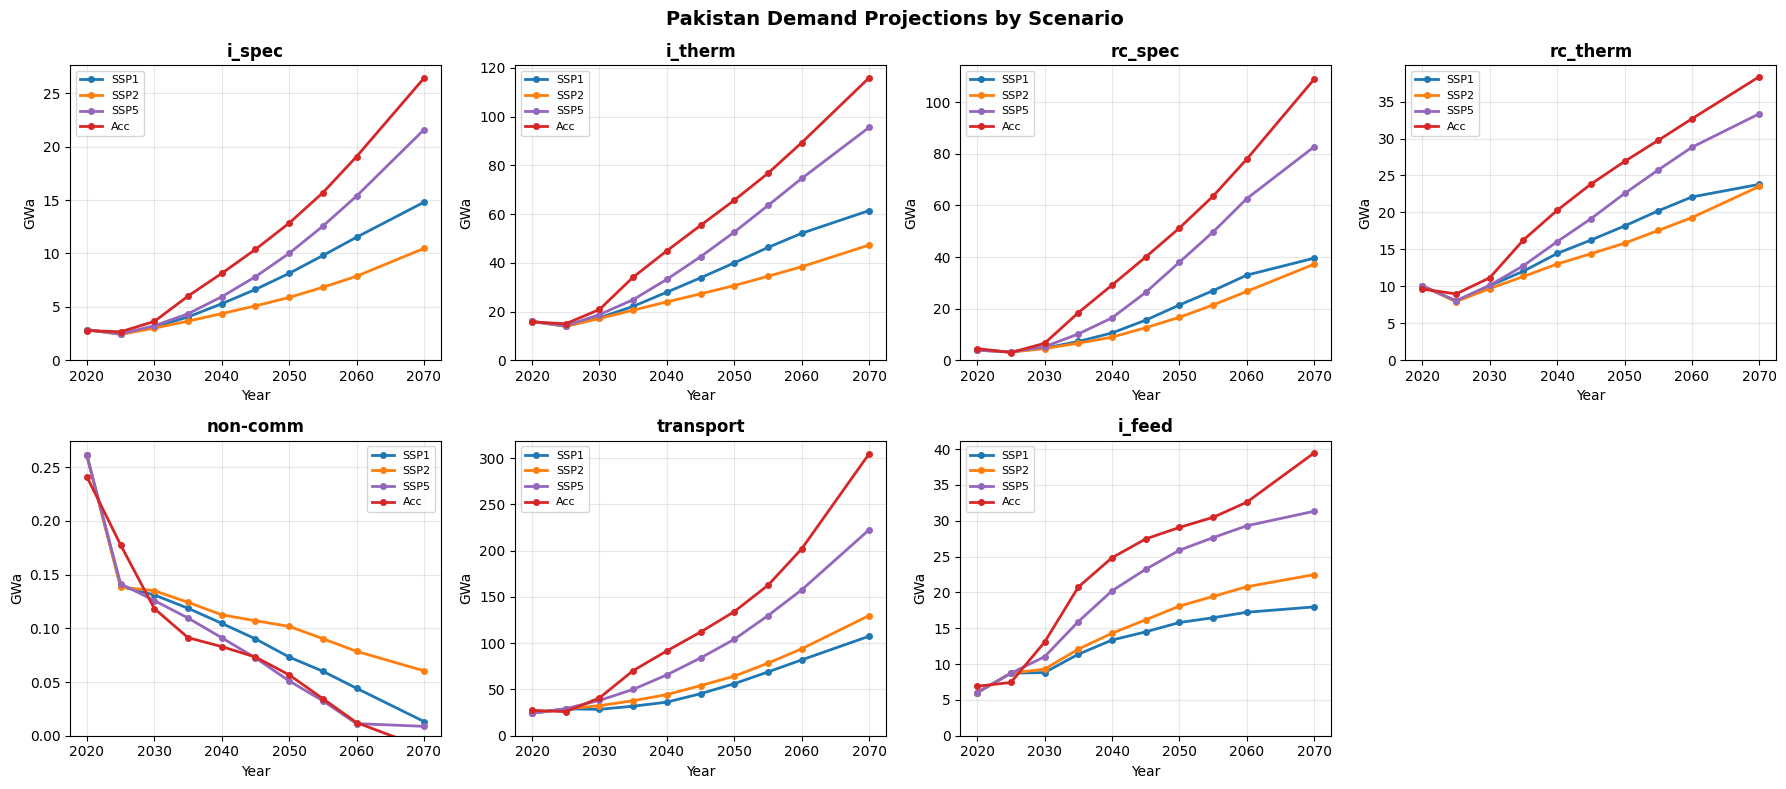

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
commodities_plot = ['i_spec', 'i_therm', 'rc_spec', 'rc_therm', 'non-comm', 'transport', 'i_feed']
colors = {'SSP1': '#1f77b4', 'SSP2': '#ff7f0e', 'SSP5': '#9467bd', 'Acc': '#d62728'}

for idx, cmdty in enumerate(commodities_plot):
    ax = axes.flatten()[idx]
    for ssp, df in projected_demands.items():
        d = df[(df['node'] == 'R12_PAK') & (df['commodity'] == cmdty)].sort_values('year')
        if not d.empty:
            ax.plot(d['year'], d['value'], marker='o', label=ssp,
                    color=colors[ssp], linewidth=2, markersize=4)
    ax.set_title(cmdty, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('GWa')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

axes.flatten()[-1].axis('off')
fig.suptitle('Pakistan Demand Projections by Scenario', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
